# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
DATA_PATH = "Train_data.csv"

import pandas as pd

df = pd.read_csv(DATA_PATH)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# 1. LOAD THE DATA

df_integrated = pd.read_csv('prepared_network_intrusion_data.csv')

RANDOM_SEED = 42
TEST_SIZE = 0.2

# 2. VERIFY TARGET COLUMN

TARGET_COL = 'class_normal' 

X = df_integrated.drop(columns=[TARGET_COL])
y = df_integrated[TARGET_COL]

# 3. SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"✅ Data loaded and split successfully.")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

✅ Data loaded and split successfully.
Training set: 20153 samples
Test set:     5039 samples


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [4]:
modelling_techniques = {
    "problem_type": "Binary Classification",
    "target_variable": "class",
    "candidate_models": [
        {
            "name": "Logistic Regression",
            "library": "sklearn.linear_model.LogisticRegression",
            "justification": "Simple baseline model for binary classification",
            "assumptions": "Linear relationship between features and target"
        },
        {
            "name": "Random Forest",
            "library": "sklearn.ensemble.RandomForestClassifier",
            "justification": "Handles complex patterns and works well with tabular data",
            "assumptions": "No strict assumptions, robust to noise"
        },
        {
            "name": "Gradient Boosting",
            "library": "sklearn.ensemble.GradientBoostingClassifier",
            "justification": "High performance model for classification tasks",
            "assumptions": "Sequential learning improves weak learners"
        }
    ]
}

print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")

for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"{i}. {model['name']} — {model['justification']}")

Problem Type: Binary Classification
Target Variable: class
1. Logistic Regression — Simple baseline model for binary classification
2. Random Forest — Handles complex patterns and works well with tabular data
3. Gradient Boosting — High performance model for classification tasks


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
TEST_SIZE = 0.2

TARGET_COL = 'class_normal'

X = df_integrated.drop(columns=[TARGET_COL])
y = df_integrated[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 20153 samples
Test set:     5039 samples


In [7]:
# Document and justify your test design
test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "",   # e.g., "5-fold cross-validation", "Hold-out"
    "stratified": True,           # True for classification, usually False for regression
    "random_seed": RANDOM_SEED,
    "justification": ""
}
# print(test_design)

---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize the dictionary
trained_models = {}

# 1. Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_lr.fit(X_train, y_train)
trained_models['Logistic Regression'] = model_lr

# 2. Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
model_rf.fit(X_train, y_train)
trained_models['Random Forest'] = model_rf

# 3. Gradient Boosting
model_gb = GradientBoostingClassifier(random_state=RANDOM_SEED)
model_gb.fit(X_train, y_train)
trained_models['Gradient Boosting'] = model_gb

print(f" Successfully trained {len(trained_models)} models.")

 Successfully trained 3 models.


In [9]:
# Optional: Hyperparameter tuning with GridSearchCV

# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [3, 5, 10, None],
#     'min_samples_split': [2, 5, 10]
# }
#
# grid_search = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=RANDOM_SEED),
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1',  # Change to an appropriate metric
#     n_jobs=-1,
#     verbose=1
# )
# grid_search.fit(X_train, y_train)
#
# print(f"Best parameters: {grid_search.best_params_}")
# print(f"Best CV score:   {grid_search.best_score_:.4f}")
#
# trained_models['Random Forest (Tuned)'] = grid_search.best_estimator_
trained_models = {}

# Logistic Regression
model_1 = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
model_1.fit(X_train, y_train)
trained_models['Logistic Regression'] = model_1

# Random Forest
model_2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
model_2.fit(X_train, y_train)
trained_models['Random Forest'] = model_2

# Gradient Boosting
model_3 = GradientBoostingClassifier(random_state=RANDOM_SEED)
model_3.fit(X_train, y_train)
trained_models['Gradient Boosting'] = model_3

print(f"✅ Trained {len(trained_models)} models")

✅ Trained 3 models


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [10]:
# TODO: Evaluate and compare all trained models.

results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).set_index('Model')

print("=== Model Comparison ===")
print(results_df.round(4))

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9643     0.9643  0.9643    0.9643
Random Forest          0.9964     0.9964  0.9964    0.9964
Gradient Boosting      0.9933     0.9933  0.9933    0.9933



=== Best Model: Random Forest ===
              precision    recall  f1-score   support

       False       1.00      0.99      1.00      2349
        True       0.99      1.00      1.00      2690

    accuracy                           1.00      5039
   macro avg       1.00      1.00      1.00      5039
weighted avg       1.00      1.00      1.00      5039



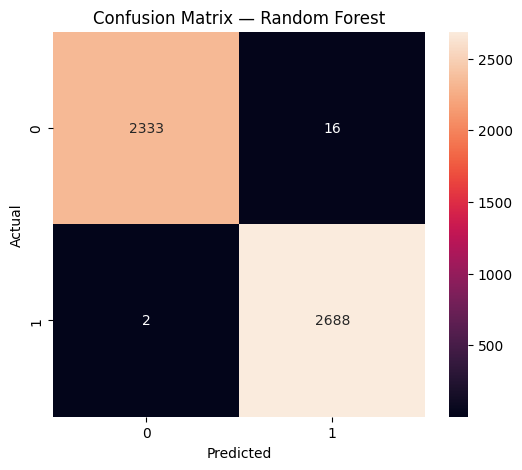

In [11]:
# Visualise results: Confusion Matrix for the best model (Classification)

# best_model_name = results_df['F1-Score'].idxmax()  # or choose manually
# best_model = trained_models[best_model_name]
# y_pred_best = best_model.predict(X_test)

# print(f"\n=== Best Model: {best_model_name} ===")
# print(classification_report(y_test, y_pred_best))

# plt.figure(figsize=(6, 5))
# cm = confusion_matrix(y_test, y_pred_best)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title(f'Confusion Matrix — {best_model_name}')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.tight_layout()
# plt.show()
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

print(f"\n=== Best Model: {best_model_name} ===")
print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
# Cross-validation for the selected best model

# cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='f1_weighted')  # Adjust metric
# print(f"Cross-Validation F1 Scores: {cv_scores.round(4)}")
# print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='f1_weighted')

print(f"CV Scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}")

CV Scores: [0.99563345 0.99741995 0.99563245 0.99702226 0.99702242]
Mean: 0.9965


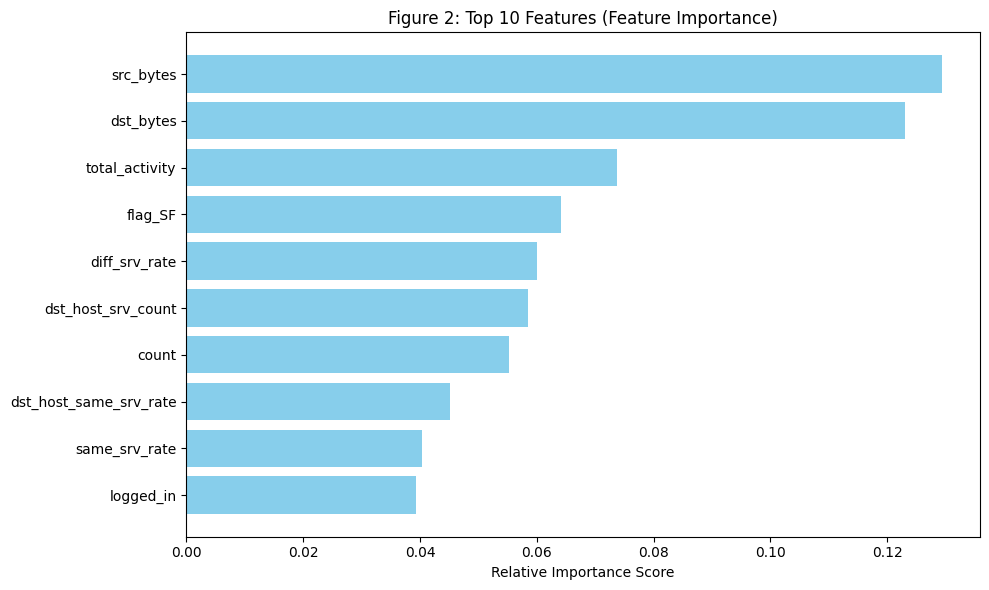

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get the importance scores from your best model
importances = best_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:]  # This picks the top 10 most important features

# 2. Create the visual
plt.figure(figsize=(10, 6))
plt.title('Figure 2: Top 10 Features (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.tight_layout()

# 3. Save the image so you can put it on your poster
plt.savefig('feature_importance.png')
plt.show()

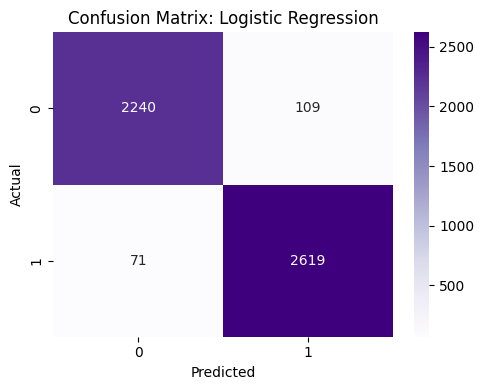

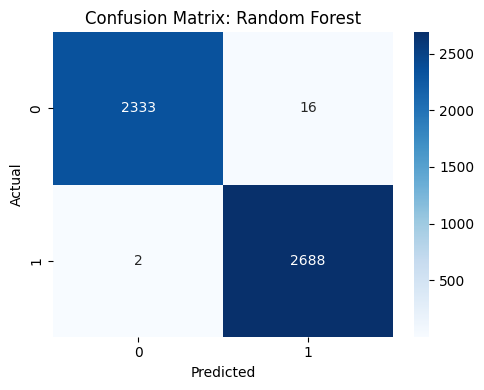

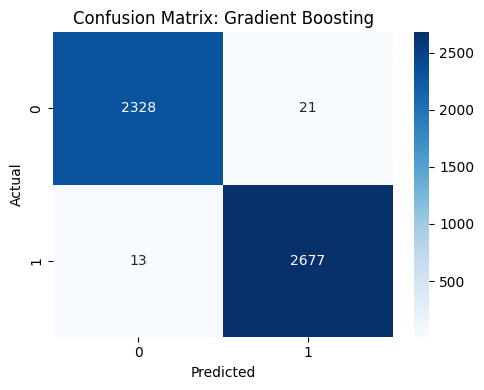

In [ ]:
import seaborn as sns

# Looping through all the models 
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    # 'd' stands for decimal (whole numbers)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples' if "Logistic" in model_name else "Blues")
    
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png')
    plt.show()